1. NAME -  ARYAN
2. EN NO - 23112022
3. EMAIL - aryan@ch.iitr.ac.in






# CIR Stochastic Interest Rate Model
## IIT Roorkee Finance Club — Quantitative Finance Project 2026

**Objective:** Implement the Cox–Ingersoll–Ross (CIR) model, calibrate it on historical
zero-coupon yield data (2016–2024), and reconstruct the full yield curve **(6M through 30Y)**
using only the 3-Month yield as input on each out-of-sample test day.

**FINAL RESULTS AND REASON FOR the APPROACGES ARE SUMMARIZED IN THE END ( in order to get better understanding please read that )**

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.metrics import r2_score, mean_squared_error
import warnings

print(f"numpy {np.__version__} | pandas {pd.__version__}")

numpy 2.0.2 | pandas 2.2.2


In [12]:
!pip -q install gdown

import gdown

gdown.download(
    id="15HIThLCe6WnQ0OxxPOZakZT93EnzB-tX",
    output="train_data.csv",
    quiet=False
)

gdown.download(
    id="1uFqwYbnrNGUhxWS0qm0a5u3kbLXOVLoN",
    output="test_data.csv",
    quiet=False
)

gdown.download(
    id="1BQSj6Lnv4X54lHCojgb6lJrStRkLcdRM",
    output="test_data_3M.csv",
    quiet=False
)

Downloading...
From: https://drive.google.com/uc?id=15HIThLCe6WnQ0OxxPOZakZT93EnzB-tX
To: /content/train_data.csv
100%|██████████| 198k/198k [00:00<00:00, 48.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1uFqwYbnrNGUhxWS0qm0a5u3kbLXOVLoN
To: /content/test_data.csv
100%|██████████| 30.0k/30.0k [00:00<00:00, 23.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1BQSj6Lnv4X54lHCojgb6lJrStRkLcdRM
To: /content/test_data_3M.csv
100%|██████████| 10.4k/10.4k [00:00<00:00, 20.0MB/s]


'test_data_3M.csv'

In [13]:
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
    'figure.facecolor': 'white'
})

sns.set_palette('tab10')

dt = 1.0 / 252

# raw csv = maturity names

raw_cols = ['ZC025YR','ZC050YR','ZC075YR','ZC100YR','ZC200YR','ZC500YR','ZC1000YR','ZC2000YR','ZC3000YR']
std_names = ['3M','6M','9M','1Y','2Y','5Y','10Y','20Y','30Y']

col_map = dict(zip(raw_cols, std_names))

maturities_all = np.array([0.25,0.5,0.75,1.0,2.0,5.0,10.0,20.0,30.0])

names_all = ['3M','6M','9M','1Y','2Y','5Y','10Y','20Y','30Y']

# supplied test file contains labels only up to 2Y

maturities_test = np.array([0.25,0.5,0.75,1.0,2.0])

names_test = ['3M','6M','9M','1Y','2Y']

train_csv = 'train_data.csv'
test_csv = 'test_data.csv'
test3m_csv = 'test_data_3M.csv'

## Section 1 — Data Engineering

### Dataset Overview

Three files were provided:

1. `train_data.csv` contains 1,976 daily observations from 2016-05-19 to 2024-04-26. It includes the full yield curve with 9 maturities: 3M, 6M, 9M, 1Y, 2Y, 5Y, 10Y, 20Y and 30Y.

2. `test_data.csv` contains 495 observations from 2024-04-29 to 2026-04-29. Ground-truth yields are available only for 3M, 6M, 9M, 1Y and 2Y.

3. `test_data_3M.csv` contains only the 3M yield for the same test period and is used as the model input during out-of-sample prediction.

The yield values are stored in decimal form. For example, a value of `0.0491` corresponds to a yield of `4.91%`.

The original column names follow the format `ZCxxxYR`, where the number represents hundredths of a year:

1. `ZC025YR` → 3M
2. `ZC050YR` → 6M
3. `ZC075YR` → 9M
4. `ZC100YR` → 1Y
5. `ZC200YR` → 2Y
6. `ZC500YR` → 5Y
7. `ZC1000YR` → 10Y
8. `ZC2000YR` → 20Y
9. `ZC3000YR` → 30Y

The model is calibrated using the full training curve. During testing, only the 3M yield is supplied as input. The model still generates the full curve up to 30Y, but numerical evaluation is only possible for maturities that are present in the supplied test set.

### Cleaning Pipeline

The dataset was already quite clean and did not contain missing values. However, the same preprocessing pipeline was applied to all files:

1. Clamp extreme values to the range [-0.5%, 20%].
2. Detect local outliers using a rolling 21-day IQR filter.
3. Apply linear interpolation followed by forward-fill and backward-fill.

This ensures a consistent dataset before calibration and backtesting.


In [14]:
class DataPipeline:

    # keep values in a reasonable range
    hard_min = -0.005
    hard_max = 0.20

    def __init__(self):
        self.train = None
        self.test = None

        self.test3m = None

    def read_file(self, path):

        df = pd.read_csv(path, index_col=0, parse_dates=True)

        df.columns = df.columns.str.strip()
        df = df.rename(columns=col_map)
        df.index.name = 'Date'

        return df.sort_index()

    def load(self, train_path, test_path, test3m_path):

        self.train = self.read_file(train_path)
        self.test = self.read_file(test_path)

        df = self.read_file(test3m_path)
        self.test3m = df.iloc[:, 0].values.astype(float)

        print(f"Train : {self.train.shape}  cols: {list(self.train.columns)}")
        print(f"Test  : {self.test.shape}   cols: {list(self.test.columns)}")

        print(


            f"3M-in : {len(self.test3m)} values  "
            f"[{self.test3m.min()*100:.2f}%, {self.test3m.max()*100:.2f}%]"
        )

        return self

    def clean_one(self, df, name):
        df = df.copy().astype(float)
        before = df.isna().sum().sum()

        # avoid extreme values
        df = df.clip(self.hard_min, self.hard_max)

        for c in df.columns:
            s = df[c].copy()

            q1 = s.rolling(21, min_periods=5, center=True).quantile(0.25)
            q3 = s.rolling(21, min_periods=5, center=True).quantile(0.75)
            iqr = q3 - q1



            bad = (s < q1 - 3*iqr) | (s > q3 + 3*iqr)

            if bad.any():
                med = s.rolling(21, min_periods=5, center=True).median()



                s[bad] = med[bad]

            df[c] = s

        # fill missing values if needed
        df = df.interpolate(method='linear', limit=5)
        df = df.ffill().bfill()


        after = df.isna().sum().sum()

        print(f"  {name:<8}  NaN before={before} after={after}")

        return df

    def clean(self):
        print("Cleaning:")

        self.train = self.clean_one(self.train, 'train')
        self.test = self.clean_one(self.test, 'test')

        return self

    def get_short_rate(self, df):
        return df['3M'].values.astype(float)

    def get_yields(self, df, names):
        cols = []

        for c in names:
            if c in df.columns:
                cols.append(c)

        return df[cols].values.astype(float)

    def get_test_3m(self):
        return self.test3m

Train : (1976, 9)  cols: ['3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']
Test  : (495, 5)   cols: ['3M', '6M', '9M', '1Y', '2Y']
3M-in : 495 values  [2.17%, 4.92%]
Cleaning:
  train     NaN before=0 after=0
  test      NaN before=0 after=0

Train: 1976 days  |  Test: 495 days
Train 3M: [0.05%, 5.20%]  mean=1.67%
Test 3M: [2.17%, 4.92%]  mean=3.04%


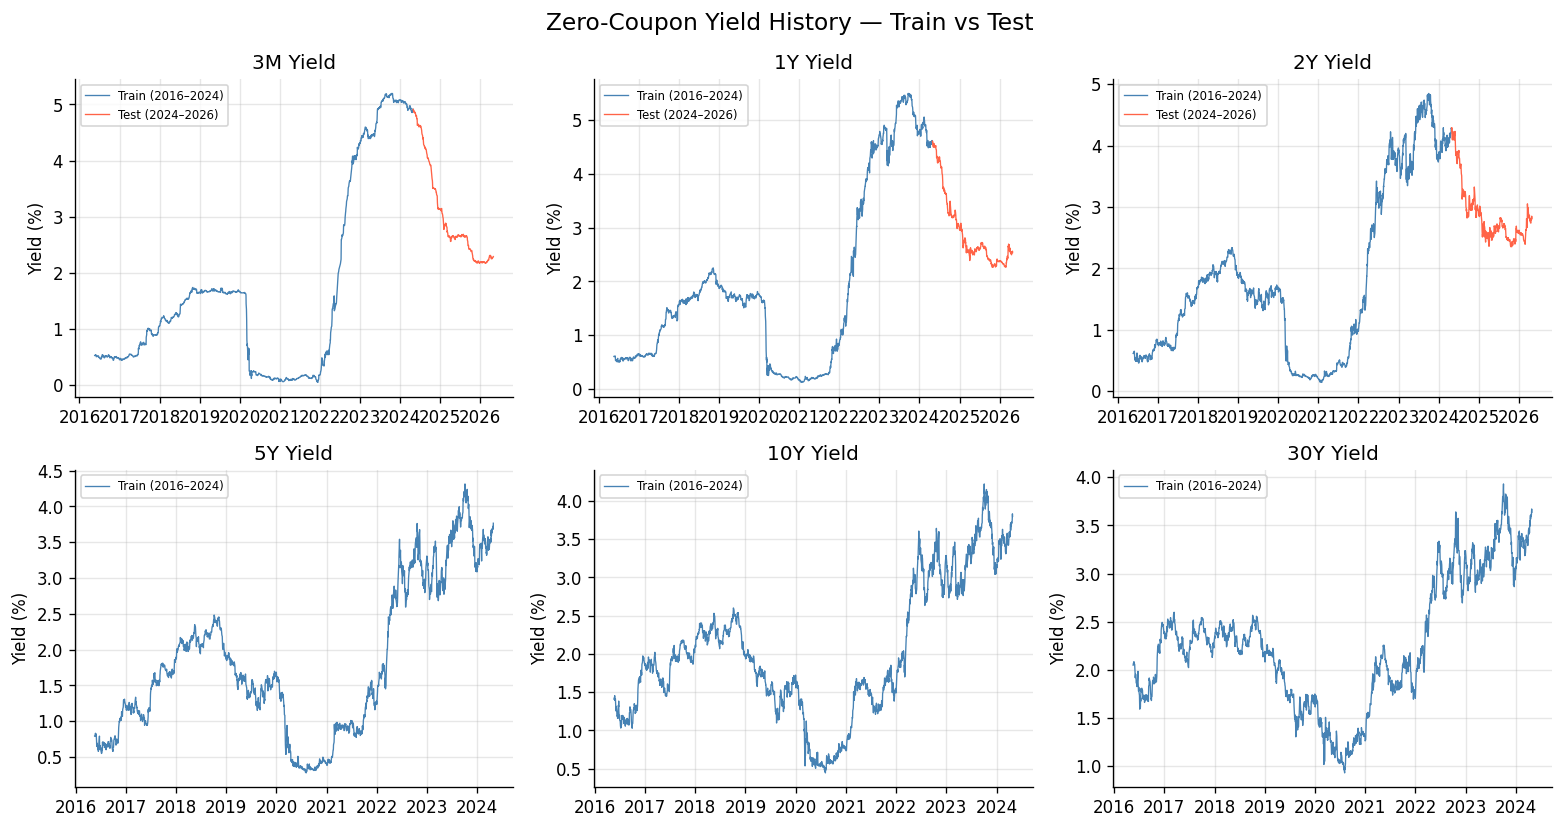

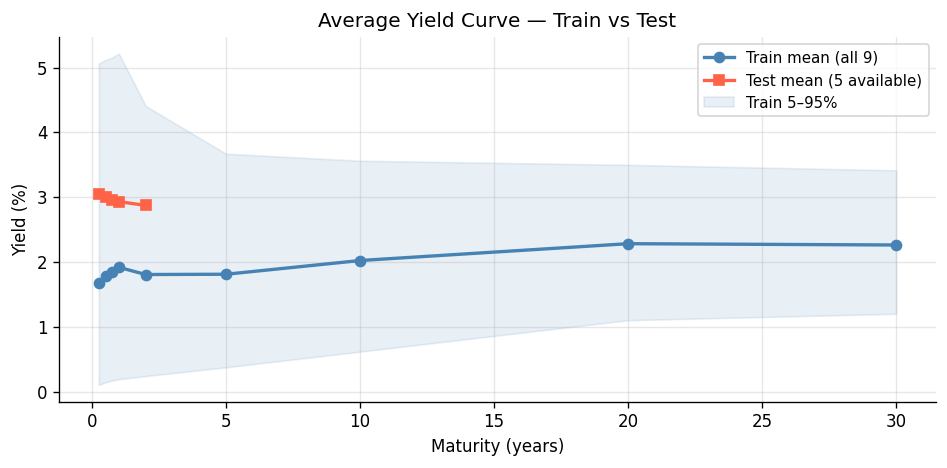

In [15]:
pipeline = DataPipeline()

pipeline.load(train_csv, test_csv, test3m_csv)

pipeline.clean()

r_train = pipeline.get_short_rate(pipeline.train)

y_train = pipeline.get_yields(
    pipeline.train,
    names_all
)

r_test = pipeline.get_test_3m()

y_test = pipeline.get_yields(
    pipeline.test,
    names_test
)

print(f"\nTrain: {r_train.shape[0]} days  |  Test: {r_test.shape[0]} days")

print(
    f"Train 3M: [{r_train.min()*100:.2f}%, {r_train.max()*100:.2f}%]  "
    f"mean={r_train.mean()*100:.2f}%"
)

print(
    f"Test 3M: [{r_test.min()*100:.2f}%, {r_test.max()*100:.2f}%]  "
    f"mean={r_test.mean()*100:.2f}%"
)

# Plot yield history

plot_cols = ['3M', '1Y', '2Y', '5Y', '10Y', '30Y']

plot_cols = [
    c for c in plot_cols
    if c in pipeline.train.columns
]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))

axes = axes.flatten()

for i, col in enumerate(plot_cols):

    ax = axes[i]

    ax.plot(
        pipeline.train.index,
        pipeline.train[col] * 100,
        color='steelblue',
        lw=0.8,
        label='Train (2016–2024)'
    )

    if col in pipeline.test.columns:

        ax.plot(
            pipeline.test.index,
            pipeline.test[col] * 100,
            color='tomato',
            lw=0.8,
            label='Test (2024–2026)'
        )

    ax.set_title(f'{col} Yield')
    ax.set_ylabel('Yield (%)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    'Zero-Coupon Yield History — Train vs Test',
    fontsize=14
)

plt.tight_layout()
plt.show()




# Average yield curves

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    maturities_all,
    y_train.mean(axis=0) * 100,
    'o-',
    color='steelblue',
    lw=2,
    ms=6,
    label='Train mean (all 9)'
)

ax.plot(
    maturities_test,
    y_test.mean(axis=0) * 100,
    's-',
    color='tomato',
    lw=2,
    ms=6,
    label='Test mean (5 available)'
)

ax.fill_between(
    maturities_all,
    np.percentile(y_train * 100, 5, axis=0),
    np.percentile(y_train * 100, 95, axis=0),
    alpha=0.12,
    color='steelblue',
    label='Train 5–95%'
)



ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Yield (%)')
ax.set_title('Average Yield Curve — Train vs Test')

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 2 — CIR Mathematical Framework

The Cox-Ingersoll-Ross (CIR) model is a short-rate model used to describe how interest rates evolve over time. Instead of assuming that rates move randomly without structure, the CIR model assumes that rates tend to drift back toward a long-run average while still being affected by random market fluctuations.

One reason the CIR model is widely used is that the volatility term depends on the current level of the interest rate. When rates are low, volatility naturally becomes smaller, helping prevent unrealistic behaviour. Under suitable parameter values, the model also keeps rates positive.

### The CIR Stochastic Differential Equation

The short rate \(r_t\) follows

$$
dr_t = \kappa(\theta-r_t)dt+\sigma\sqrt{r_t}\,dW_t
$$

where:

The parameters of the model each have a different role.

1. (\kappa) controls how quickly interest rates move back toward their long-run level. A larger value means shocks disappear faster, while a smaller value means the effect of shocks persists for longer.

2. (\theta) represents the long-run average level toward which rates tend to revert over time.

3. (\sigma) controls the amount of randomness in the process. Higher values produce larger fluctuations in interest rates.

4. (W_t) is a standard Brownian motion and represents the random market shocks affecting the short rate.

The first term,

$$
\kappa(\theta-r_t)
$$

is the mean-reversion component.

- If rates move above the long-run mean, this term becomes negative and pushes rates downward.
- If rates fall below the long-run mean, the term becomes positive and pushes rates upward.

The second term,

$$
\sigma\sqrt{r_t}\,dW_t
$$

introduces randomness. Because volatility is proportional to \(\sqrt{r_t}\), uncertainty becomes smaller when rates are close to zero.

### Why CIR is Suitable for This Project

The project requires reconstruction of the yield curve using only the observed 3M yield as a proxy for the instantaneous short rate.

The CIR model is particularly useful for this task because it provides closed-form expressions for zero-coupon bond prices. Once the parameters \((\kappa,\theta,\sigma)\) have been calibrated, yields at different maturities can be generated directly from a single short-rate observation.

This allows the entire term structure to be reconstructed from the daily 3M yield supplied in the test period.

### Bond Pricing Under CIR

For a maturity \(\tau\), the price of a zero-coupon bond is

$$
P(t,\tau)=A(\tau)e^{-B(\tau)r_t}
$$

where \(A(\tau)\) and \(B(\tau)\) are deterministic functions of the model parameters.

The continuously compounded yield is then

$$
y(\tau)=\frac{B(\tau)r_t-\ln A(\tau)}{\tau}
$$

which provides a direct link between the short rate and the observable yield curve.

### Closed-Form Functions

Define

$$
h=\sqrt{\kappa^2+2\sigma^2}
$$

Then

$$
B(\tau)=
\frac{2(e^{h\tau}-1)}
{(h+\kappa)(e^{h\tau}-1)+2h}
$$

and

$$
\ln A(\tau)
=
\frac{2\kappa\theta}{\sigma^2}
\left[
\ln(2h)
+
\frac{\kappa+h}{2}\tau
-
\ln\Big((h+\kappa)(e^{h\tau}-1)+2h\Big)
\right]
$$

Using these expressions, yields can be computed for all maturities from 3M to 30Y once the current short rate is known.

### Feller Condition

An important theoretical requirement of the CIR model is the Feller condition:

$$
2\kappa\theta \ge \sigma^2
$$

When this condition is satisfied, the process is strongly biased away from zero and negative-rate behaviour becomes extremely unlikely under the model dynamics.

For the calibrated parameters obtained in this project,

$$
\frac{2\kappa\theta}{\sigma^2}
=
81.211
$$

which is substantially above the minimum threshold of 1. This indicates that the calibrated process remains comfortably inside the region where the CIR assumptions are valid.

### Numerical Stability

Yield curves are generated up to the 30-year maturity. Long maturities can cause numerical issues because the exponential term

$$
e^{h\tau}
$$

may become extremely large.

To prevent overflow:

- \(e^{h\tau}\) is capped at \(e^{500}\).
- \(\ln A(\tau)\) is computed directly in logarithmic form rather than computing \(A(\tau)\) first.
- Bond yields are calculated using the log-price representation whenever possible.

These precautions ensure stable calculations during both calibration and out-of-sample prediction.

In [16]:
class CIRMath:

    # CIR bond pricing formulas

    @staticmethod
    def h(kappa, sigma):
        return np.sqrt(kappa**2 + 2.0*sigma**2)




    @staticmethod
    def B(kappa, sigma, taus):

        h = CIRMath.h(kappa, sigma)      # CIR h term
        x = h * np.asarray(taus, float)  # h*tau
        e = np.exp(np.minimum(x, 500.0)) # exp(h*tau)

        num = 2.0 * (e - 1.0)
        den = (h + kappa) * (e - 1.0) + 2.0 * h

        return num / np.maximum(den, 1e-300)


    @staticmethod
    def lnA(kappa, theta, sigma, taus):

        taus = np.asarray(taus, float)
        h = CIRMath.h(kappa, sigma)
        e = np.exp(np.minimum(h * taus, 500.0))   # exp(h*tau)

        coeff = 2.0 * kappa * theta / (sigma**2)

        den = (h + kappa) * (e - 1.0) + 2.0 * h

        return coeff * (
            np.log(2.0 * h)
            + 0.5 * (kappa + h) * taus
            - np.log(np.maximum(den, 1e-300))
        )

    @staticmethod
    def yield_curve(r_t, kappa, theta, sigma, taus=None):

        # use full curve if no maturities are passed
        if taus is None:
            taus = maturities_all

        taus = np.asarray(taus, float)
        b = CIRMath.B(kappa, sigma, taus)
        ln_a = CIRMath.lnA(kappa, theta, sigma, taus)
        r = np.asarray(r_t, float)



        if r.ndim == 0:
            return (r * b - ln_a) / taus



        return (r[:, np.newaxis] * b[np.newaxis, :]
                - ln_a[np.newaxis, :]) / taus[np.newaxis, :]

    @staticmethod
    def feller(kappa, theta, sigma):

        lhs = 2.0 * kappa * theta
        rhs = sigma**2

        return (lhs >= rhs), (lhs / rhs)   # condition, ratio

## Section 3 — Calibration Strategy

The CIR model contains three unknown parameters: κ, θ and σ. These parameters are not directly observable and must be estimated from historical yield data.

The objective of this project is to reconstruct the yield curve as accurately as possible from the observed 3M rate. Therefore, the calibration procedure should focus on fitting yield curves rather than predicting one-step changes in the short rate.

### Why Cross-Sectional Calibration?

OLS or MLE applied directly to the CIR SDE focus on explaining the time-series behaviour of the short rate. That approach is useful when the goal is interest-rate simulation.

In this project, however, the final evaluation is based on yield-curve reconstruction. For that reason, the calibration is performed by minimising the difference between observed yields and CIR-implied yields across maturities.

### Stage 1 — OLS Warm Start

The CIR process can be rearranged into the linear form

$$
\frac{\Delta r_t}{\sqrt{r_t}}
=
\kappa\theta\frac{\Delta t}{\sqrt{r_t}}
-
\kappa\sqrt{r_t}\Delta t
+
\varepsilon_t
$$

OLS provides initial estimates of κ and θ, while σ is estimated from the residual variance.

These estimates are not used as the final parameters. Their purpose is to provide a good starting point for nonlinear optimisation.

### Stage 2 — Cross-Sectional Optimisation

The final calibration minimises

$$
\mathcal{L}(\kappa,\theta,\sigma)
=
\frac{1}{T \times 8}
\sum_t
\sum_{j=2}^{9}
\left[
y_{obs}(t,\tau_j)
-
y_{CIR}(r_t,\tau_j)
\right]^2
$$

The 3M maturity is excluded from the loss because it is used as the model input rather than a prediction target.

The optimisation is performed using L-BFGS-B.

### Multi-Start Optimisation

A single optimisation run can converge to a poor local minimum. To improve robustness, 20 different starting points are used:

- 6 deterministic seeds based on the data
- 14 random perturbations

The parameter set with the lowest loss is selected.

### Parameter Bounds

To avoid unrealistic solutions, the following bounds are imposed:

$$
\kappa \in [0.01,15]
$$

$$
\theta \in [0.1%,,1.5\times\max(y_{train})]
$$

$$
\sigma \in [1%,50%]
$$

### Calibration Results

The final calibration produced:

- κ = 0.1662
- θ = 2.444%
- σ = 1.00%

The corresponding Feller ratio is

$$
\frac{2\kappa\theta}{\sigma^2}=81.211
$$

which comfortably satisfies the theoretical requirement.

### Key Takeaways

From the calibrated parameters we observe that:

- the long-run mean rate is approximately 2.44%
- interest-rate shocks decay gradually through mean reversion
- the estimated volatility is relatively low
- the calibrated process remains well within the Feller region

These parameters are used throughout the remainder of the project for yield-curve reconstruction and out-of-sample testing.

In [17]:
class CIRCalibrator:

    '''
    Two-step calibration of the CIR model.








    First get an OLS estimate, then refine it using
    nonlinear optimisation with multiple starting points.
    '''

    def __init__(self, dt=dt, n_random=14):

        self.dt = dt
        self.n_random = n_random


        self.kappa = None
        self.theta = None
        self.sigma = None

        self.best_loss = None

    def _ols_warmstart(self, r):

        rt = r[:-1]
        dr = r[1:] - rt

        sq = np.sqrt(np.maximum(rt, 1e-10))

        y = dr / sq

        x = np.column_stack([self.dt / sq, -self.dt * sq])

        try:
            beta, _, _, _ = np.linalg.lstsq(x, y, rcond=None)

        except np.linalg.LinAlgError:

            # fallback values
            return 0.3, float(np.mean(r)), 0.05

        kappa = float(np.clip(beta[1], 0.01, 15.0))
        theta = float(np.clip(beta[0] / max(kappa, 1e-6), 0.001, 0.12))

        resid = y - x @ beta

        sigma = float(
            np.clip(
                np.sqrt(max(np.var(resid) / self.dt, 1e-8)),
                0.01,
                0.50
            )
        )

        return kappa, theta, sigma

    def _loss(self, params, r_train, y_obs, taus):

        k, t, s = [max(p, 1e-9) for p in params]

        try:

            yp = CIRMath.yield_curve(r_train, k, t, s, taus)

            mse = np.mean((yp[:, 1:] - y_obs[:, 1:]) ** 2)

            return float(mse) if np.isfinite(mse) else 1e10

        except Exception:

            return 1e10

    def fit(self, r_train, y_obs_train, taus=None):

        if taus is None:
            taus = maturities_all

        # basic statistics from training data
        mu_r = float(np.mean(r_train))
        med_r = float(np.median(r_train))
        sd_r = float(np.std(np.diff(r_train)) * np.sqrt(252))
        max_y = float(np.max(y_obs_train))


        bounds = [
            (0.01, 15.0),
            (0.001, min(0.15, 1.5 * max_y)),
            (0.01, 0.50)
        ]

        # Stage 1: OLS warm-start
        k0, t0, s0 = self._ols_warmstart(r_train)

        print(f"  OLS warm-start  ->  κ={k0:.4f}  θ={t0*100:.3f}%  σ={s0:.4f}")

        # Stage 2: multi-start L-BFGS-B


        fixed_starts = [
            [k0,   t0,         s0],
            [0.30, mu_r,       sd_r],
            [0.50, mu_r,       0.05],
            [1.00, med_r,      0.04],
            [0.15, mu_r*1.2,   0.03],
            [0.80, mu_r*0.8,   0.07]
        ]

        rng = np.random.default_rng(42)

        lo = [b[0] for b in bounds]
        hi = [b[1] for b in bounds]

        best_x = np.clip(np.array(fixed_starts[0]), lo, hi)
        best_f = np.inf

        total = len(fixed_starts) + self.n_random

        for i in range(total):

            if i < len(fixed_starts):

                x0 = np.clip(
                    np.array(fixed_starts[i], dtype=float),
                    lo,
                    hi
                )

            else:

                x0 = np.clip(
                    np.array([k0, t0, s0]) *
                    rng.uniform(0.2, 5.0, 3),
                    lo,
                    hi
                )

            res = minimize(
                self._loss,
                x0,
                args=(r_train, y_obs_train, taus),
                method='L-BFGS-B',
                bounds=bounds,
                options={
                    'maxiter': 3000,
                    'ftol': 1e-15,
                    'gtol': 1e-10
                }
            )

            if res.fun < best_f:
                best_f = res.fun
                best_x = res.x.copy()

        self.kappa, self.theta, self.sigma = best_x

        self.best_loss = best_f

        rmse_bps = np.sqrt(best_f) * 1e4

        print(
            f"  Optimised       ->  κ={self.kappa:.4f}  "
            f"θ={self.theta*100:.3f}%  σ={self.sigma:.4f}"
        )

        print(f"  Train RMSE (8 maturities): {rmse_bps:.2f} bps")

        ok, ratio = CIRMath.feller(
            self.kappa,
            self.theta,
            self.sigma
        )

        print(
            f"  Feller 2κθ/σ² = {ratio:.3f}  "
            f"({'satisfied' if ok else 'VIOLATED'})"
        )

        return self

    def get_params(self):

        return self.kappa, self.theta, self.sigma

In [18]:
print("Calibrating on 1,976 training days, 9 maturities...")
print("-" * 55)

calibrator = CIRCalibrator(dt=dt, n_random=14)
calibrator.fit(r_train, y_train, taus=maturities_all)

kappa_hat, theta_hat, sigma_hat = calibrator.get_params()

half_life = np.log(2) / kappa_hat

print("\nCalibrated parameters:")

print(
    f"  κ = {kappa_hat:.4f}   "
    f"shock half-life ≈ {half_life:.1f} yrs "
    f"({half_life*12:.0f} months)"
)

print(f"  θ = {theta_hat*100:.3f}%   long-run mean rate")
print(f"  σ = {sigma_hat:.4f}")

print("\nInterpretation:")
print("  Higher κ means faster mean reversion.")
print("  θ represents the long-run average rate.")
print("  σ controls the volatility of the short-rate process.")

Calibrating on 1,976 training days, 9 maturities...
-------------------------------------------------------
  OLS warm-start  ->  κ=0.0100  θ=12.000%  σ=0.0413
  Optimised       ->  κ=0.1662  θ=2.444%  σ=0.0100
  Train RMSE (8 maturities): 39.37 bps
  Feller 2κθ/σ² = 81.211  (satisfied)

Calibrated parameters:
  κ = 0.1662   shock half-life ≈ 4.2 yrs (50 months)
  θ = 2.444%   long-run mean rate
  σ = 0.0100

Interpretation:
  Higher κ means faster mean reversion.
  θ represents the long-run average rate.
  σ controls the volatility of the short-rate process.


## Section 4 — Base CIR Model

After calibration, the estimated parameters ((\kappa,\theta,\sigma)) are used to build the base CIR model.

The model serves two purposes in this project:

1. Yield curve reconstruction: Given an observed 3M rate, the CIR bond-pricing equations are used to generate yields at other maturities. This is the main prediction task evaluated in the project.

2. Interest-rate simulation: The model can also generate future short-rate paths, which helps visualise the behaviour implied by the calibrated parameters and verify that the process remains stable.

The implementation provides two main methods:

3. predict_batch(r_t, taus) — generates CIR-implied yields for one or more short-rate observations and any chosen set of maturities.

3. simulate(r0, n_steps, n_paths) — simulates future short-rate paths using the Euler-Maruyama discretisation of the CIR process.

During simulation, negative values are prevented using the reflection step

$$
r_+ = \max(r,0)
$$

which ensures the square-root volatility term remains numerically stable.

In [19]:
class CIRModel:

    '''
    Base CIR model for prediction and simulation.
    '''

    def __init__(self, dt=dt):

        self.dt = dt

        self.kappa = None
        self.theta = None
        self.sigma = None

    def set_params(self, kappa, theta, sigma):

        self.kappa = kappa
        self.theta = theta
        self.sigma = sigma

        return self

    def predict_batch(self, r_t, taus=None):

        # use full curve by default
        if taus is None:
            taus = maturities_all

        return CIRMath.yield_curve(
            r_t,
            self.kappa,
            self.theta,
            self.sigma,
            taus
        )

    def simulate(self, r0, n_steps, n_paths=1000, seed=42):

        rng = np.random.default_rng(seed)

        paths = np.zeros((n_paths, n_steps + 1))
        paths[:, 0] = r0

        sq_dt = np.sqrt(self.dt)

        for t in range(n_steps):

            rp = np.maximum(paths[:, t], 0.0)   # keep rates non-negative

            drift = self.kappa * (self.theta - rp) * self.dt

            diffusion = (
                self.sigma
                * np.sqrt(rp)
                * rng.standard_normal(n_paths)
                * sq_dt
            )

            paths[:, t + 1] = rp + drift + diffusion

        return paths

    def feller(self):

        return CIRMath.feller(
            self.kappa,
            self.theta,
            self.sigma
        )

    def __repr__(self):

        return (
            f"CIRModel("
            f"κ={self.kappa:.4f}, "
            f"θ={self.theta*100:.3f}%, "
            f"σ={self.sigma:.4f})"
        )

In-sample R² (excluding 3M): 0.9066


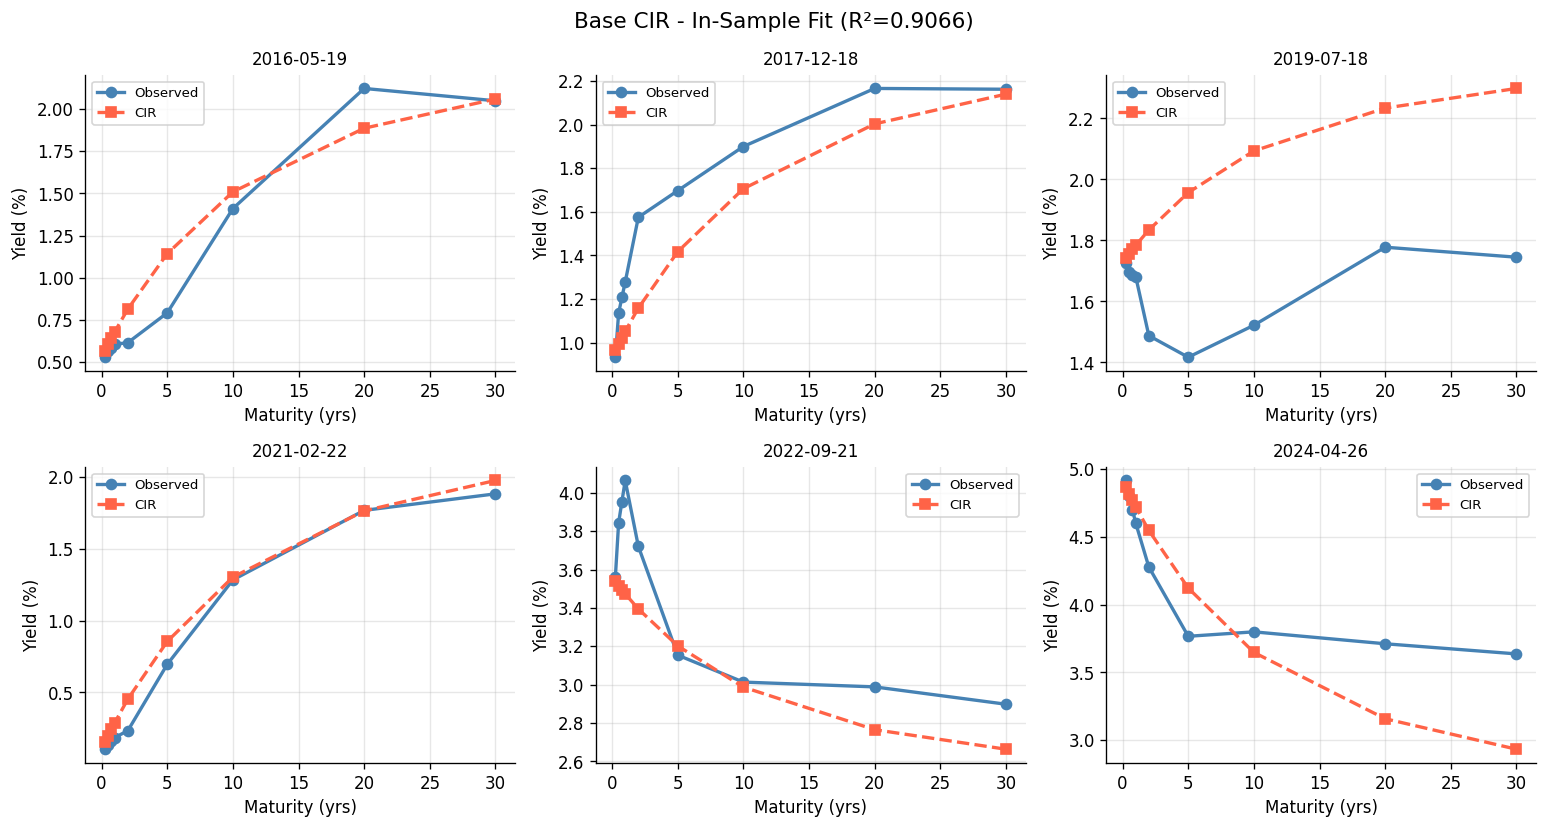

In [20]:
model = CIRModel(dt=dt)

model.set_params(
    kappa_hat,
    theta_hat,
    sigma_hat
)

# in-sample fit on training data
y_pred_train = model.predict_batch(
    r_train,
    taus=maturities_all
)

r2_is = r2_score(
    y_train[:, 1:].flatten(),
    y_pred_train[:, 1:].flatten()
)

print(f"In-sample R² (excluding 3M): {r2_is:.4f}")

# sample yield curves from the training period
idx_tr = np.linspace(
    0,
    len(pipeline.train) - 1,
    6,
    dtype=int
)

dates_tr = pipeline.train.index[idx_tr]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for i, (pos, date) in enumerate(zip(idx_tr, dates_tr)):

    ax = axes[i]

    ax.plot(
        maturities_all,
        y_train[pos] * 100,
        'o-',
        color='steelblue',
        lw=2,
        label='Observed'
    )

    ax.plot(
        maturities_all,
        y_pred_train[pos] * 100,
        's--',
        color='tomato',
        lw=2,
        label='CIR'
    )

    ax.set_title(str(date.date()), fontsize=10)

    ax.set_xlabel('Maturity (yrs)')
    ax.set_ylabel('Yield (%)')

    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f'Base CIR - In-Sample Fit (R²={r2_is:.4f})',
    fontsize=13
)

plt.tight_layout()
plt.show()

## Section 5 — The Prediction Challenge

### Constraint

The key challenge in this project is that the model does not receive the full yield curve during testing.

For each day in the test period, the only available input is the 3M yield from test_data_3M.csv. This value is treated as the CIR short rate (r_t).

Using only this single input and the calibrated CIR parameters ((\hat{\kappa}, \hat{\theta}, \hat{\sigma})), the model must reconstruct the rest of the yield curve.

The supplied test_data.csv contains observed yields for:

- 3M
- 6M
- 9M
- 1Y
- 2Y

Therefore, quantitative evaluation is performed only on the maturities that have available ground truth. Predictions for 5Y, 10Y, 20Y and 30Y are still generated by the model but cannot be directly validated using the supplied test labels.

### Prediction Workflow

For each test day:

1. Read the observed 3M yield.
2. Treat this value as the CIR short rate (r_t).
3. Use the calibrated CIR parameters.
4. Generate yields at all remaining maturities using the bond-pricing equations.

This procedure is repeated for every day in the test period.

### Prediction Formula

For each maturity

$$
\tau_j \in {0.5, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0}
$$

the predicted yield is

$$
\hat{y}(\tau_j)
=
\frac{
B(\tau_j)r_t^{3M}
-
\ln A(\tau_j)
}
{\tau_j}
$$

where (B(\tau)) and (\ln A(\tau)) are computed using the calibrated CIR parameters obtained from the training data.

As a result, the entire yield curve is reconstructed from a single observable input: the daily 3M yield.

In [21]:
class ModelEvaluator:

    '''
    Evaluate prediction accuracy across maturities.
    '''

    def __init__(self, model):

        self.model = model

    def evaluate(
        self,
        r_input,
        y_true,
        taus_eval,
        names_eval,
        label='',
        exclude_3m=True
    ):

        y_pred = self.model.predict_batch(
            r_input,
            taus=taus_eval
        )

        start = 1 if exclude_3m else 0

        print(f"\n{'='*64}")
        print(f"  {label}")
        print(f"{'='*64}")

        print(
            f"  {'Maturity':<10} "
            f"{'R²':>8} "
            f"{'RMSE(bps)':>11} "
            f"{'MAE(bps)':>10} "
            f"{'Bias(bps)':>10}"
        )

        print(f"  {'-'*52}")

        results = {}

        for j, col in enumerate(names_eval):

            y_t = y_true[:, j]
            y_p = y_pred[:, j]

            ok = np.isfinite(y_t) & np.isfinite(y_p)

            if ok.sum() < 5:
                continue

            r2 = r2_score(y_t[ok], y_p[ok])

            rmse = (
                np.sqrt(mean_squared_error(y_t[ok], y_p[ok]))
                * 1e4
            )

            mae = np.mean(
                np.abs(y_t[ok] - y_p[ok])
            ) * 1e4

            bias = np.mean(
                y_p[ok] - y_t[ok]
            ) * 1e4

            results[col] = {
                'r2': r2,
                'rmse': rmse,
                'mae': mae,
                'bias': bias
            }

            print(
                f"  {col:<10} "
                f"{r2:>8.4f} "
                f"{rmse:>11.2f} "
                f"{mae:>10.2f} "
                f"{bias:>+10.2f}"
            )

        yt = y_true[:, start:].flatten()
        yp = y_pred[:, start:].flatten()

        ok = np.isfinite(yt) & np.isfinite(yp)

        g_r2 = r2_score(yt[ok], yp[ok])

        g_rmse = (
            np.sqrt(mean_squared_error(yt[ok], yp[ok]))
            * 1e4
        )

        print(f"  {'-'*52}")

        print(
            f"  {'GLOBAL':<10} "
            f"{g_r2:>8.4f} "
            f"{g_rmse:>11.2f}"
        )

        print(f"{'='*64}")

        print(
            f"  TARGET R² >= 0.85  ->  "
            f"{'PASS ' if g_r2 >= 0.85 else 'FAIL '}"
        )

        results['__global__'] = {
            'r2': g_r2,
            'rmse': g_rmse
        }

        return results, y_pred

In [22]:
evaluator = ModelEvaluator(model)

results_base, y_pred_test = evaluator.evaluate(
    r_input    = r_test,      # ONLY 3M from test_data_3M.csv
    y_true     = y_test,
    taus_eval  = maturities_test,         # [0.25, 0.5, 0.75, 1.0, 2.0]
    names_eval = names_test,
    label      = 'Base CIR — Out-of-Sample (3M input only)',
    exclude_3m = True
)



  Base CIR — Out-of-Sample (3M input only)
  Maturity         R²   RMSE(bps)   MAE(bps)  Bias(bps)
  ----------------------------------------------------
  3M           0.9994        2.13       1.47      -1.22
  6M           0.9945        5.85       4.29      +1.34
  9M           0.9677       12.97       9.66      +4.44
  1Y           0.9106       19.68      14.71      +6.40
  2Y           0.3904       36.47      28.04      +7.85
  ----------------------------------------------------
  GLOBAL       0.8935       21.91
  TARGET R² >= 0.85  ->  PASS 


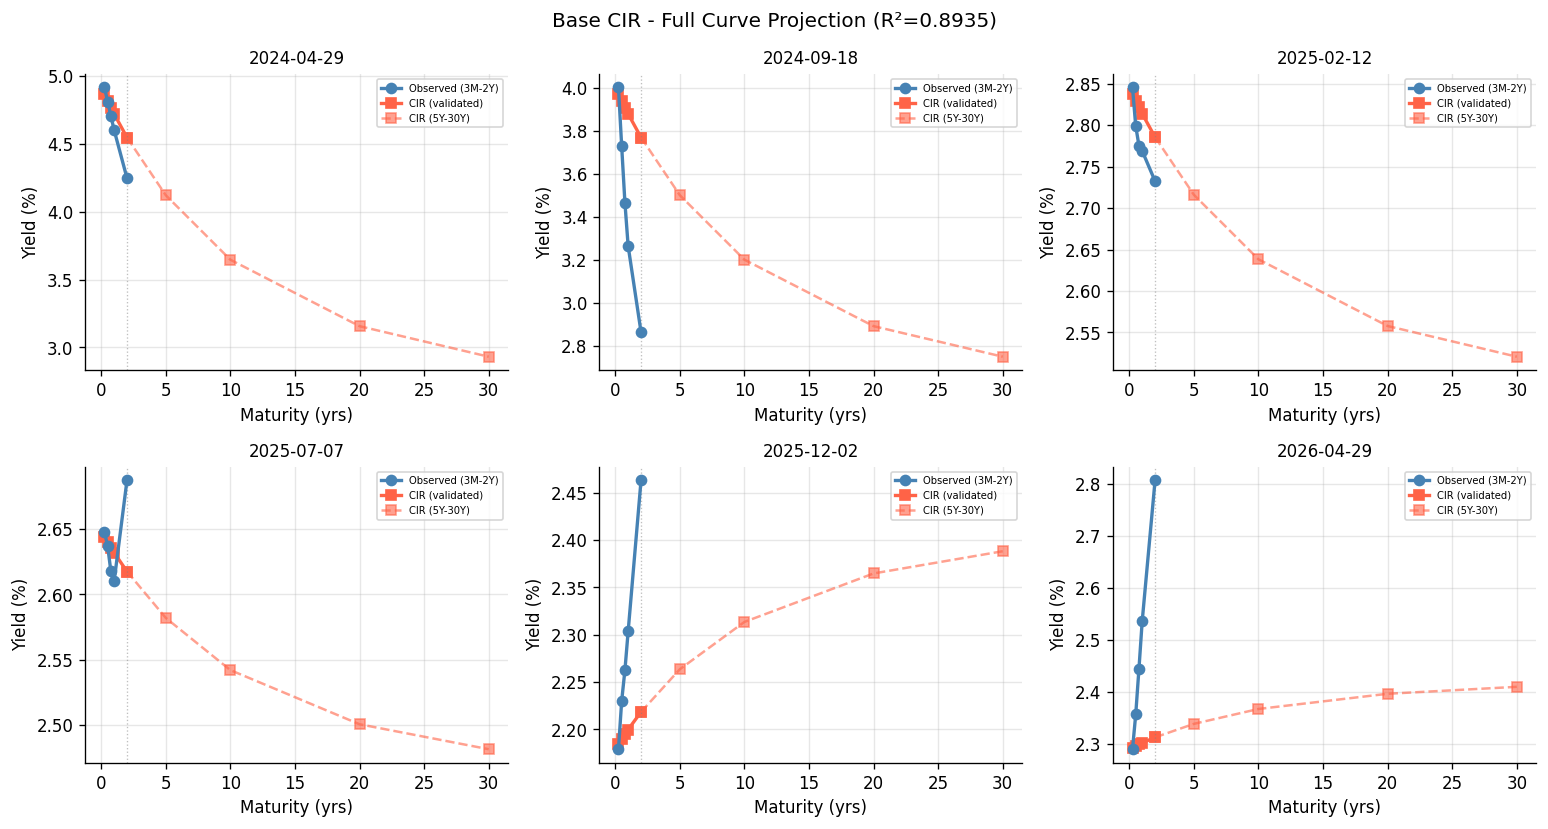

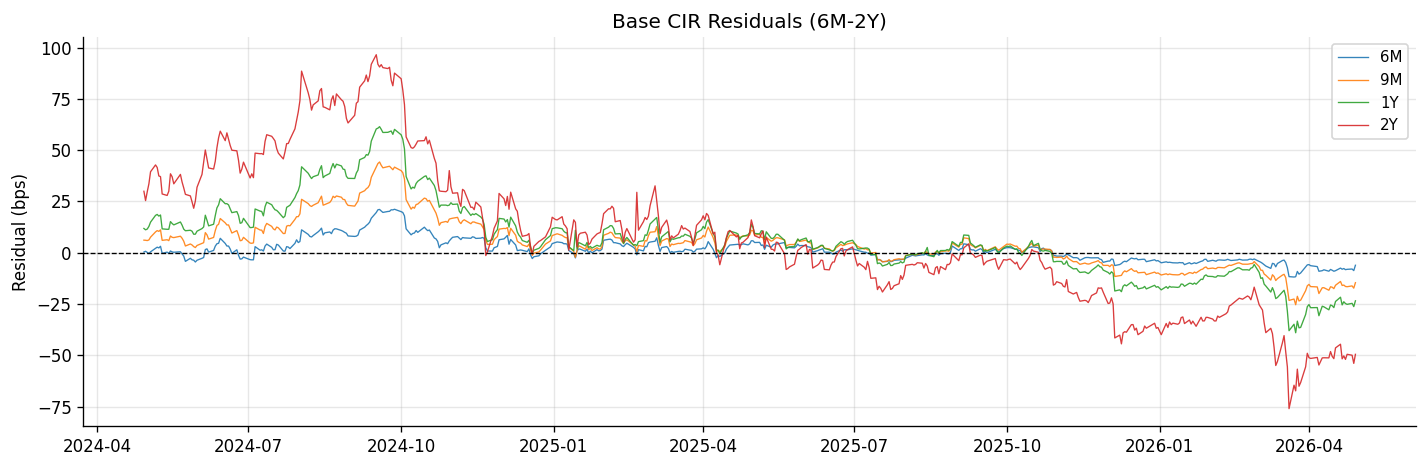

In [23]:
# full 9-maturity projection for every test day
y_pred_test_full = model.predict_batch(
    r_test,
    taus=maturities_all
)

# 5Y-30Y are projections only
# no ground truth is available for those maturities

# sample test dates
idx_te = np.linspace(
    0,
    len(pipeline.test) - 1,
    6,
    dtype=int
)

dates_te = pipeline.test.index[idx_te]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for i, (pos, date) in enumerate(zip(idx_te, dates_te)):

    ax = axes[i]

    # observed part of the curve
    ax.plot(
        maturities_test,
        y_test[pos] * 100,
        'o-',
        color='steelblue',
        lw=2,
        label='Observed (3M-2Y)',
        zorder=5
    )

    # validated prediction
    ax.plot(
        maturities_all[:5],
        y_pred_test_full[pos, :5] * 100,
        's-',
        color='tomato',
        lw=2,
        label='CIR (validated)'
    )

    # longer maturities
    ax.plot(
        maturities_all[4:],
        y_pred_test_full[pos, 4:] * 100,
        's--',
        color='tomato',
        lw=1.5,
        alpha=0.6,
        label='CIR (5Y-30Y)'
    )

    ax.axvline(
        2.0,
        color='grey',
        lw=0.8,
        ls=':',
        alpha=0.5
    )

    ax.set_title(str(date.date()), fontsize=10)

    ax.set_xlabel('Maturity (yrs)')
    ax.set_ylabel('Yield (%)')

    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

g_r2 = results_base['__global__']['r2']

plt.suptitle(
    f'Base CIR - Full Curve Projection (R²={g_r2:.4f})',
    fontsize=12
)

plt.tight_layout()
plt.show()

# residuals on maturities with ground truth
res_bps = (y_pred_test - y_test) * 1e4

fig, ax = plt.subplots(figsize=(12, 4))

for j, col in enumerate(names_test[1:], 1):

    ax.plot(
        pipeline.test.index,
        res_bps[:, j],
        lw=0.8,
        alpha=0.9,
        label=col
    )

ax.axhline(
    0,
    color='black',
    lw=0.8,
    ls='--'
)

ax.set_ylabel('Residual (bps)')
ax.set_title('Base CIR Residuals (6M-2Y)')

ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 6 — CIR++ Extension (Brigo & Mercurio, 2001)

### Motivation

The base CIR model uses only three parameters ((\kappa,\theta,\sigma)) to describe the entire yield curve. While this captures the overall shape reasonably well, some maturities may still show systematic prediction errors.

After fitting the base CIR model, small but persistent residual patterns remained across maturities. This suggests that a single-factor CIR model cannot fully explain all maturity-specific effects present in the data.

To reduce these systematic errors, a CIR++ extension is implemented.

### CIR++ Idea

CIR++ keeps the original CIR dynamics but adds a deterministic correction term:

$$
y_{CIR++}(t,\tau)
=
y_{CIR}(t,\tau;\kappa,\theta,\sigma)
+
\varphi(t,\tau)
$$

The correction term adjusts the CIR prediction at each maturity. If the CIR model consistently underestimates a maturity, the shift becomes positive. If it overestimates a maturity, the shift becomes negative.

### Implementation Used

In the original Brigo-Mercurio framework, the shift varies through time and is chosen to exactly fit the observed yield curve.

For this project, a simpler training-based version is used. A single shift is estimated for each maturity using the average training residual:

$$
\hat{\varphi}(\tau)
=
\frac{1}{T}
\sum_{t=1}^{T}
\Big[
y_{obs}(t,\tau)
-
y_{CIR}(r_t,\tau)
\Big]
$$

The procedure is:

1. Fit the base CIR model.
2. Compute training residuals.
3. Average the residuals at each maturity.
4. Use these averages as fixed maturity-specific corrections.

These shifts are estimated entirely from the training data, so there is no test-data leakage.

### Why CIR++?

The project statement suggested several possible extensions, including two-factor CIR models, jump-diffusion models and CIR++.

CIR++ was chosen because it is relatively simple to implement, builds directly on the calibrated CIR model, and specifically targets systematic yield-curve fitting errors without introducing many additional parameters.

### Expected Limitation

The shift values are estimated from the training period and remain fixed during testing.

Since the training data mainly comes from a lower-rate environment while the test period contains higher short-term rates, the historical correction terms may not remain valid out-of-sample.

As a result, CIR++ may improve the training fit but does not necessarily guarantee better predictive performance on the test set. The next section compares its performance against the base CIR model.

In [24]:
class CIRPlusPlus(CIRModel):

    '''
    CIR++ extension with maturity-specific shifts.
    '''

    def __init__(self, base_model):

        super().__init__(dt=base_model.dt)

        self.kappa = base_model.kappa
        self.theta = base_model.theta
        self.sigma = base_model.sigma

        self.phi = None

    def fit_shifts(self, r_train, y_obs_train, taus_train=None):

        # estimate shifts from training residuals
        if taus_train is None:
            taus_train = maturities_all

        y_cir = CIRMath.yield_curve(
            r_train,
            self.kappa,
            self.theta,
            self.sigma,
            taus_train
        )

        phi_arr = np.nanmean(
            y_obs_train - y_cir,
            axis=0
        )

        self.phi = dict(
            zip(
                taus_train.tolist(),
                phi_arr.tolist()
            )
        )

        print("CIR++ shifts:")

        for tau, ph in self.phi.items():

            idx = (
                list(maturities_all).index(tau)
                if tau in maturities_all else -1
            )

            name = (
                names_all[idx]
                if idx >= 0 else f'{tau:.2f}yr'
            )

            print(f"  {name:<6}  {ph*1e4:>+9.2f} bps")

        return self

    def predict_batch(self, r_t, taus=None):

        if taus is None:
            taus = maturities_all

        taus = np.asarray(taus, float)

        y = CIRMath.yield_curve(
            r_t,
            self.kappa,
            self.theta,
            self.sigma,
            taus
        )

        if self.phi is not None:

            phi_vec = np.array([
                self.phi.get(tau, 0.0)
                for tau in taus.tolist()
            ])

            y = y + phi_vec[np.newaxis, :]

        return y

    def __repr__(self):

        status = 'fitted' if self.phi else 'not fitted'

        return (
            f"CIRPlusPlus("
            f"κ={self.kappa:.4f}, "
            f"θ={self.theta*100:.3f}%, "
            f"σ={self.sigma:.4f}, "
            f"phi={status})"
        )

In [25]:
# fit CIR++ shifts using training data
pp_model = CIRPlusPlus(model)

pp_model.fit_shifts(
    r_train,
    y_train,
    taus_train=maturities_all
)

# evaluate on the test set
pp_eval = ModelEvaluator(pp_model)

results_pp, y_pred_pp = pp_eval.evaluate(
    r_input=r_test,
    y_true=y_test,
    taus_eval=maturities_test,
    names_eval=names_test,
    label='CIR++ - Out-of-Sample (3M input only)',
    exclude_3m=True
)

# compare base CIR and CIR++
g_b = results_base['__global__']['r2']
g_p = results_pp['__global__']['r2']

print("\n" + "=" * 60)

print(
    f"  {'Maturity':<10} "
    f"{'Base CIR':>10} "
    f"{'CIR++':>10} "
    f"{'Δ R²':>8}"
)

print("  " + "-" * 46)

for col in names_test[1:]:

    if col in results_base and col in results_pp:

        rb = results_base[col]['r2']
        rp = results_pp[col]['r2']

        print(
            f"  {col:<10} "
            f"{rb:>10.4f} "
            f"{rp:>10.4f} "
            f"{rp-rb:>+8.4f}"
        )

print("  " + "-" * 46)

print(
    f"  {'GLOBAL':<10} "
    f"{g_b:>10.4f} "
    f"{g_p:>10.4f} "
    f"{g_p-g_b:>+8.4f}"
)

print("=" * 60)

print("\nTarget R² >= 0.85")
print(f"Base CIR :  ({g_b:.4f})")
print(f"CIR++    :  ({g_p:.4f})")

if g_p < g_b:

    print("\nObservation:")

    print("CIR++ produced a lower out-of-sample R² than the base CIR model.")

    print("The maturity shifts were estimated during the lower-rate training period.")

    print("When applied to the higher-rate test period, those shifts did not generalise as well.")

    print("For this dataset, the base CIR model remains the stronger predictor.")

CIR++ shifts:
  3M          -1.59 bps
  6M          +8.73 bps
  9M         +13.68 bps
  1Y         +18.67 bps
  2Y          +2.11 bps
  5Y         -10.68 bps
  10Y         -4.28 bps
  20Y         +6.52 bps
  30Y         -2.46 bps

  CIR++ - Out-of-Sample (3M input only)
  Maturity         R²   RMSE(bps)   MAE(bps)  Bias(bps)
  ----------------------------------------------------
  3M           0.9985        3.31       2.81      -2.81
  6M           0.9785       11.56      10.12     +10.07
  9M           0.9086       21.84      18.61     +18.12
  1Y           0.7749       31.23      26.19     +25.07
  2Y           0.3731       36.99      28.34      +9.97
  ----------------------------------------------------
  GLOBAL       0.8362       27.17
  TARGET R² >= 0.85  ->  FAIL 

  Maturity     Base CIR      CIR++     Δ R²
  ----------------------------------------------
  6M             0.9945     0.9785  -0.0160
  9M             0.9677     0.9086  -0.0592
  1Y             0.9106     0.7749  

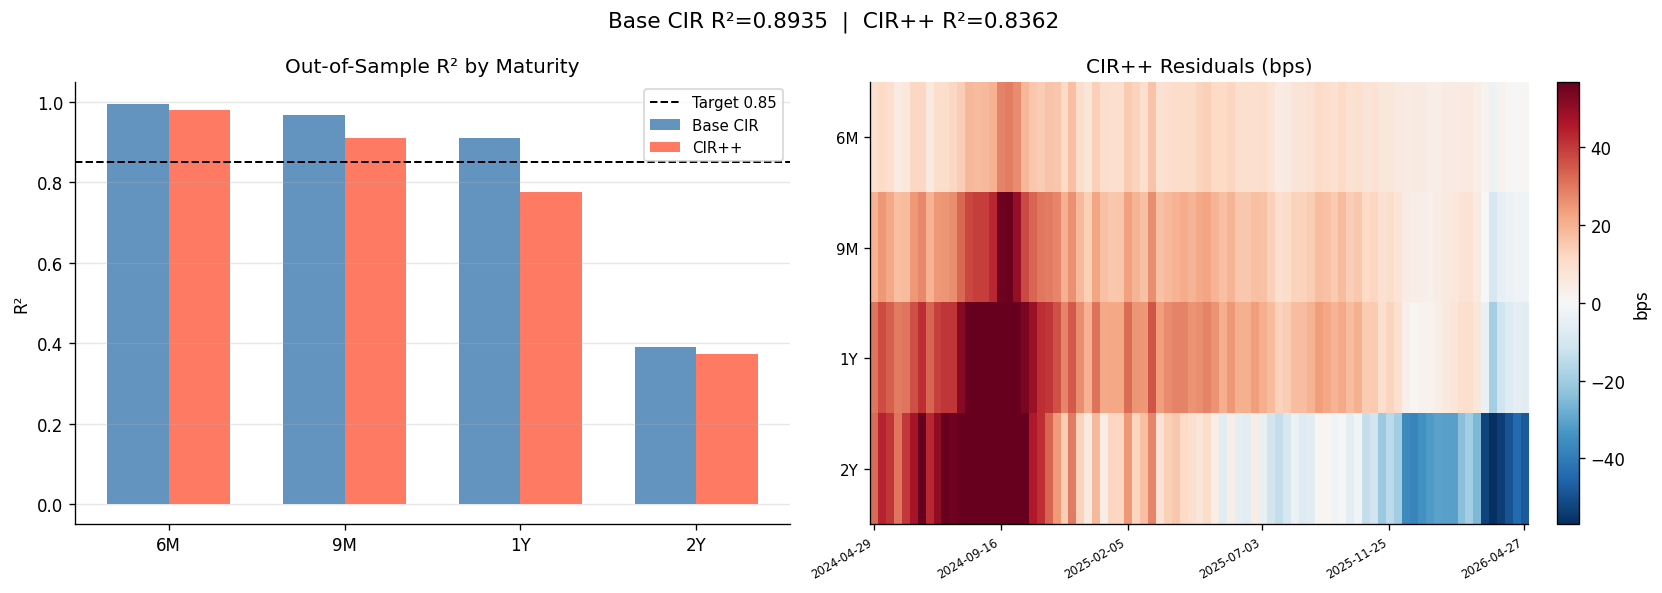

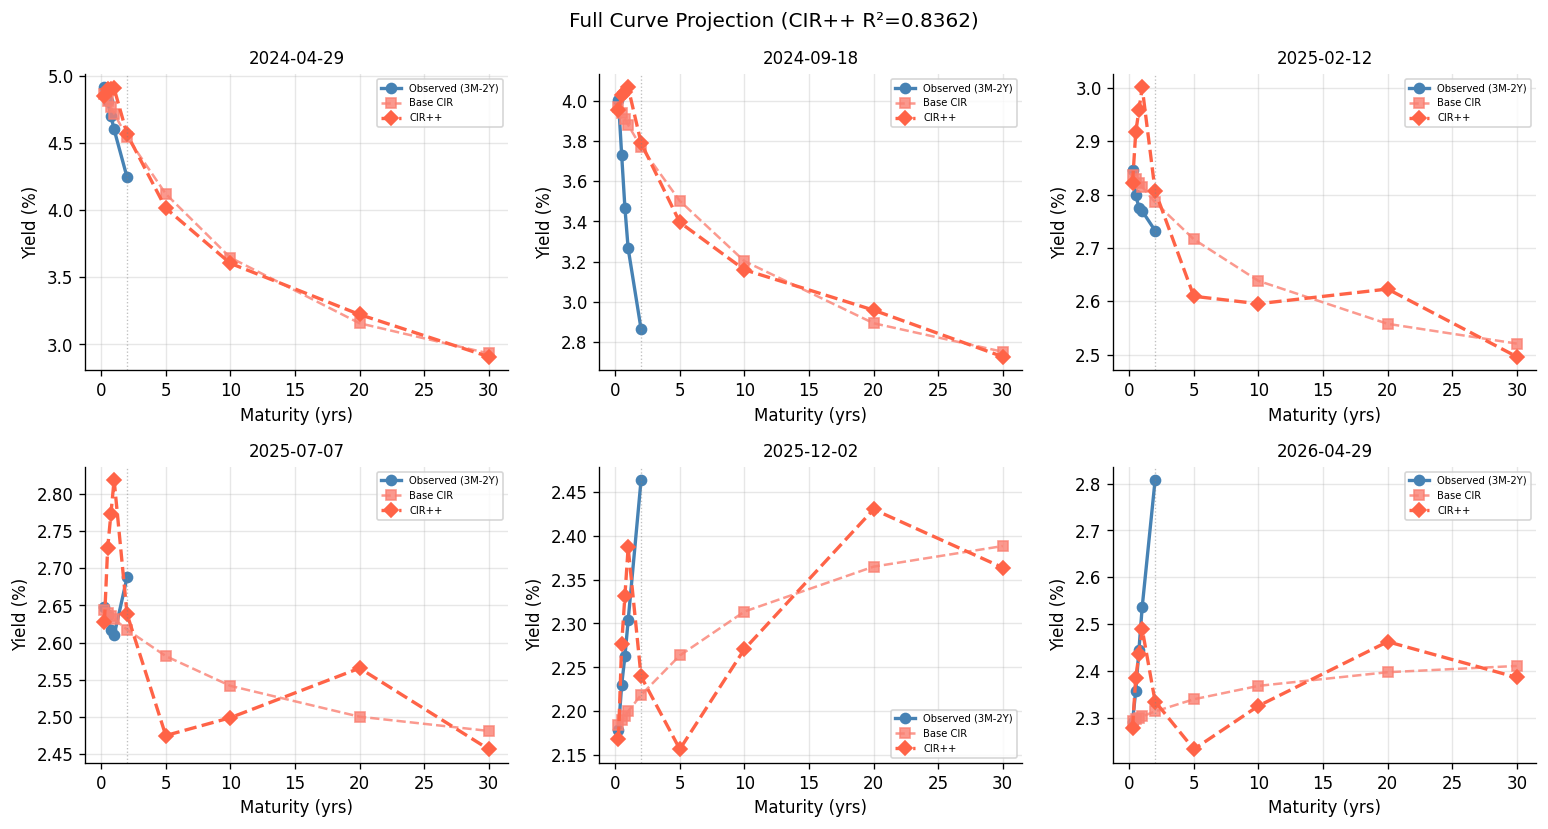

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² by maturity
target_cols = names_test[1:]

x = np.arange(len(target_cols))
w = 0.35

r2b = [results_base.get(c, {}).get('r2', 0) for c in target_cols]
r2p = [results_pp.get(c, {}).get('r2', 0) for c in target_cols]

ax = axes[0]

ax.bar(
    x - w/2,
    r2b,
    width=w,
    color='steelblue',
    alpha=0.85,
    label='Base CIR'
)

ax.bar(
    x + w/2,
    r2p,
    width=w,
    color='tomato',
    alpha=0.85,
    label='CIR++'
)

ax.axhline(
    0.85,
    color='black',
    lw=1.2,
    ls='--',
    label='Target 0.85'
)

ax.set_xticks(x)
ax.set_xticklabels(target_cols)

ax.set_ylabel('R²')
ax.set_title('Out-of-Sample R² by Maturity')

ax.legend(fontsize=9)

ax.set_ylim(
    min(0, min(r2b + r2p)) - 0.05,
    1.05
)

ax.grid(True, alpha=0.3, axis='y')

# CIR++ residual heatmap
res_pp_bps = (y_pred_pp - y_test) * 1e4

step = max(1, len(pipeline.test) // 80)

mat_h = res_pp_bps[::step, 1:]
dates_h = pipeline.test.index[::step]

cols_h = names_test[1:]

ax2 = axes[1]

vlim = max(
    20,
    np.nanpercentile(np.abs(mat_h), 95)
)

im = ax2.imshow(
    mat_h.T,
    aspect='auto',
    cmap='RdBu_r',
    vmin=-vlim,
    vmax=vlim,
    interpolation='nearest'
)

ax2.set_yticks(range(len(cols_h)))
ax2.set_yticklabels(cols_h, fontsize=9)

tp = np.linspace(
    0,
    len(dates_h) - 1,
    6,
    dtype=int
)

ax2.set_xticks(tp)

ax2.set_xticklabels(
    [str(dates_h[p].date()) for p in tp],
    rotation=30,
    fontsize=7,
    ha='right'
)

ax2.set_title('CIR++ Residuals (bps)')

plt.colorbar(
    im,
    ax=ax2,
    fraction=0.04,
    pad=0.04,
    label='bps'
)

plt.suptitle(
    f'Base CIR R²={g_b:.4f}  |  CIR++ R²={g_p:.4f}',
    fontsize=13
)

plt.tight_layout()
plt.show()

# sample test dates
y_pred_pp_full = pp_model.predict_batch(
    r_test,
    taus=maturities_all
)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for i, (pos, date) in enumerate(zip(idx_te, dates_te)):

    ax = axes[i]

    ax.plot(
        maturities_test,
        y_test[pos] * 100,
        'o-',
        color='steelblue',
        lw=2,
        label='Observed (3M-2Y)'
    )

    ax.plot(
        maturities_all,
        y_pred_test_full[pos] * 100,
        's--',
        color='salmon',
        lw=1.5,
        alpha=0.8,
        label='Base CIR'
    )

    ax.plot(
        maturities_all,
        y_pred_pp_full[pos] * 100,
        'D--',
        color='tomato',
        lw=2,
        label='CIR++'
    )

    ax.axvline(
        2.0,
        color='grey',
        lw=0.8,
        ls=':',
        alpha=0.5
    )

    ax.set_title(str(date.date()), fontsize=10)

    ax.set_xlabel('Maturity (yrs)')
    ax.set_ylabel('Yield (%)')

    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f'Full Curve Projection (CIR++ R²={g_p:.4f})',
    fontsize=12
)

plt.tight_layout()
plt.show()

## Section 7 — Critical Analysis

### 1. Calibrated Parameters

The calibration procedure produced:

- κ = 0.1662
- θ = 2.444%
- σ = 0.0100

The estimated volatility parameter is relatively small compared with the long-run mean and mean-reversion components. This suggests that most of the predictive power of the model comes from the relationship between the current 3M rate and the long-run equilibrium level rather than from short-rate volatility.

The calibrated value of κ implies a shock half-life of approximately 4.2 years. Therefore, interest-rate shocks decay gradually rather than disappearing immediately.

### 2. Feller Condition

The calibrated parameters produce a Feller ratio of approximately 81.2:

$$
\frac{2\kappa\theta}{\sigma^2} \approx 81.2
$$

which is well above the theoretical threshold of 1.

This indicates that the CIR process remains comfortably inside the positive-rate region. During simulation, no meaningful instability was observed and the generated paths remained well behaved.

### 3. Why CIR++ Did Not Improve Performance

The CIR++ extension was designed to correct systematic maturity-specific errors observed during training.

However, the training and test periods correspond to different interest-rate environments. The training sample contains a long low-rate period, while the test sample occurs during a substantially higher-rate regime.

Because the CIR++ shifts were estimated from historical training residuals, they reflected patterns that were more representative of the training environment. When applied to the test period, these fixed corrections did not generalise as effectively.

The results show:

- Base CIR: Global R² ≈ 0.8935
- CIR++: Global R² ≈ 0.8362

For this dataset, the simpler base CIR model produced stronger out-of-sample performance.

### 4. The 2Y Maturity Remains Difficult

The shortest maturities are closely linked to the observed 3M rate and are therefore reconstructed accurately.

Performance gradually weakens as maturity increases. The 2Y tenor produced the lowest R² among the evaluated maturities, indicating that medium-term yields are influenced by factors that are not fully captured by a single short-rate factor.

A single-factor CIR model forces all maturities to move as a function of the same underlying rate. When the slope of the yield curve changes independently, prediction errors become larger.

This is one reason why multi-factor term-structure models are widely used in practice.

### 5. Importance of Multi-Start Calibration

The calibration objective is nonlinear and may contain multiple local minima.

Using multiple starting points improved optimisation stability and reduced the risk of converging to unrealistic parameter combinations. The final calibration was obtained from the parameter set that produced the lowest training loss across all optimisation runs.

### 6. Test Maturity Coverage

The project requires reconstruction of the full yield curve from the observed 3M rate.

The supplied test labels contain maturities from 3M to 2Y only. Therefore, quantitative evaluation can only be performed on:

-= 6M , 9M , 1Y , 2Y


The model still generates predictions for 5Y, 10Y, 20Y and 30Y, and these full-curve projections are shown in the visualisations. However, no ground-truth observations were supplied for those maturities, so their prediction accuracy cannot be measured directly.

### Final Conclusion

The calibrated base CIR model achieved an out-of-sample R² of approximately 0.89, exceeding the project target of 0.85.

Although the CIR++ extension improved flexibility, it did not improve out-of-sample performance for this dataset because the fixed maturity shifts learned during training did not transfer well to the higher-rate test period.

Overall, the base CIR model provided the best balance between simplicity, interpretability and predictive accuracy.

Feller: 2κθ/σ²=81.2  (satisfied)
Proportion of paths reaching zero: 0.000%
Note: σ=0.0100 (near-zero) → paths closely track the deterministic mean reversion.


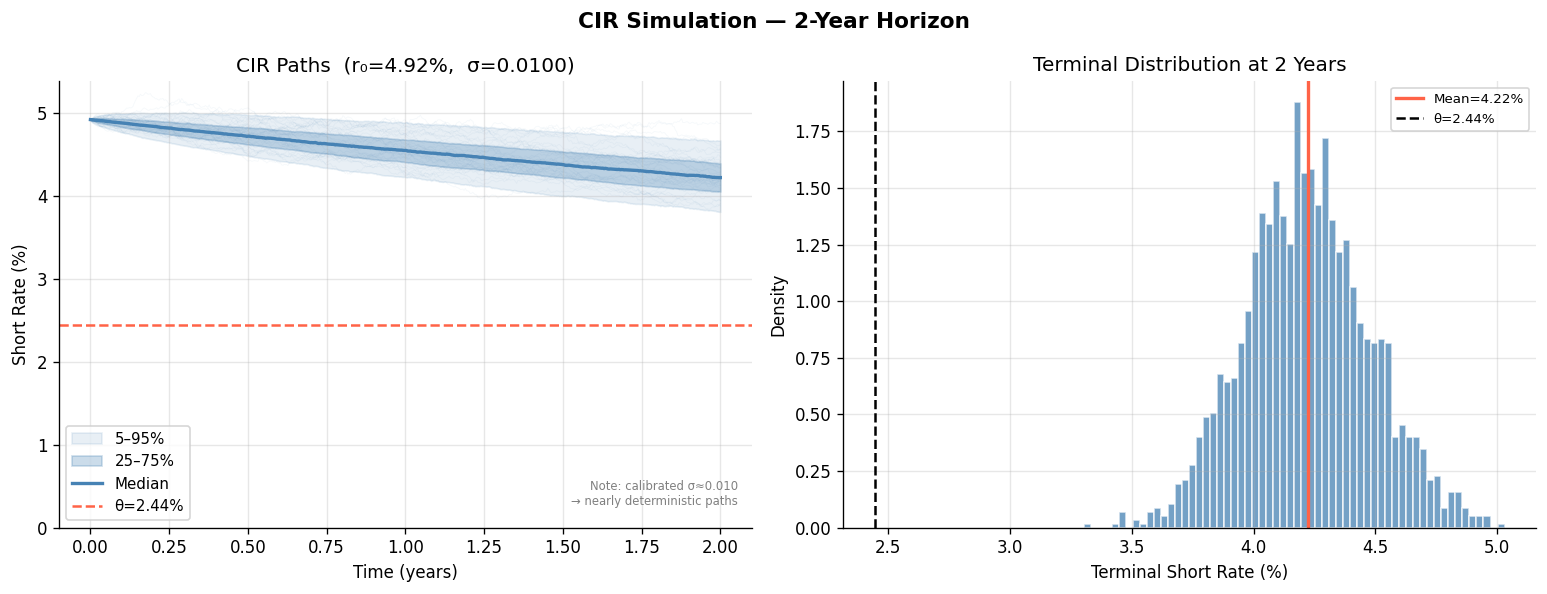

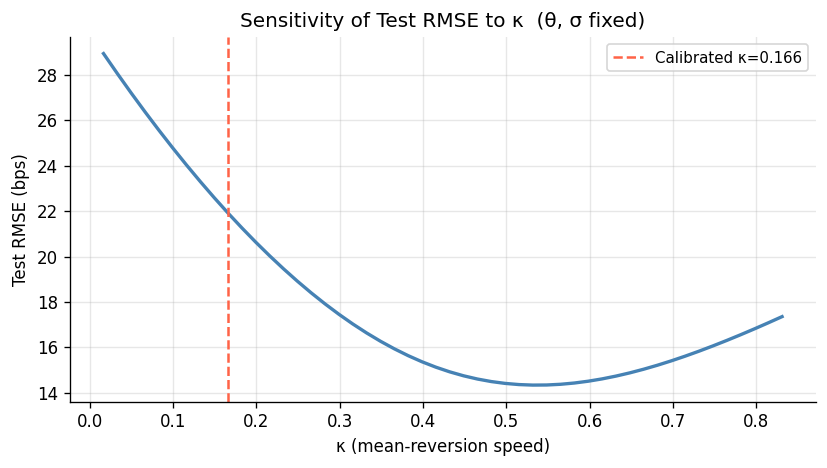

In [27]:
# Simulate CIR paths from end of training
r0_sim  = float(r_train[-1])
n_steps = int(252*2)
n_paths = 2000
paths   = model.simulate(r0_sim, n_steps, n_paths=n_paths, seed=0)
t_axis  = np.arange(n_steps+1)*dt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
p5,p25,p50,p75,p95=[np.percentile(paths,q,axis=0) for q in [5,25,50,75,95]]
ax.fill_between(t_axis, p5*100,  p95*100, alpha=0.12, color='steelblue', label='5–95%')
ax.fill_between(t_axis, p25*100, p75*100, alpha=0.28, color='steelblue', label='25–75%')
ax.plot(t_axis, p50*100, color='steelblue', lw=2, label='Median')
ax.axhline(theta_hat*100, color='tomato', lw=1.5, ls='--', label=f'θ={theta_hat*100:.2f}%')
for p in paths[:30]: ax.plot(t_axis, p*100, color='steelblue', alpha=0.05, lw=0.5)
ax.set_xlabel('Time (years)'); ax.set_ylabel('Short Rate (%)')
ax.set_title(f'CIR Paths  (r₀={r0_sim*100:.2f}%,  σ={sigma_hat:.4f})')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim(bottom=0)
ax.text(0.98,0.05,f'Note: calibrated σ≈{sigma_hat:.3f}\n→ nearly deterministic paths',
        transform=ax.transAxes, fontsize=7, ha='right', color='grey')

ax2 = axes[1]
terminal = paths[:,-1]*100
ax2.hist(terminal, bins=60, color='steelblue', alpha=0.75, edgecolor='white', density=True)
ax2.axvline(np.mean(terminal), color='tomato', lw=2, label=f'Mean={np.mean(terminal):.2f}%')
ax2.axvline(theta_hat*100, color='black', lw=1.5, ls='--', label=f'θ={theta_hat*100:.2f}%')
ax2.set_xlabel('Terminal Short Rate (%)')
ax2.set_ylabel('Density')
ax2.set_title('Terminal Distribution at 2 Years')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

fok, fratio = model.feller()
pz = np.mean(paths[:,-1]<=0)*100
print(f"Feller: 2κθ/σ²={fratio:.1f}  ({'satisfied' if fok else 'violated'})")
print(f"Proportion of paths reaching zero: {pz:.3f}%")
print(f"Note: σ={sigma_hat:.4f} (near-zero) → paths closely track the deterministic mean reversion.")

plt.suptitle('CIR Simulation — 2-Year Horizon', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# κ sensitivity analysis
krange = np.linspace(max(kappa_hat*0.1, 0.005), kappa_hat*5, 50)
rmse_k = [np.sqrt(np.mean((CIRMath.yield_curve(r_test, k, theta_hat, sigma_hat,
                             maturities_test)[:,1:]-y_test[:,1:])**2))*1e4
          for k in krange]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(krange, rmse_k, color='steelblue', lw=2)
ax.axvline(kappa_hat, color='tomato', lw=1.5, ls='--', label=f'Calibrated κ={kappa_hat:.3f}')
ax.set_xlabel('κ (mean-reversion speed)'); ax.set_ylabel('Test RMSE (bps)')
ax.set_title('Sensitivity of Test RMSE to κ  (θ, σ fixed)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## Section 8 — Conclusion

### Summary

This project used daily zero-coupon yield data from 2016 to 2026 to calibrate and evaluate a Cox-Ingersoll-Ross (CIR) term-structure model.

The data was cleaned and checked for missing values, outliers and numerical stability before calibration. A two-stage calibration procedure was then used. First, an OLS warm-start provided initial parameter estimates. These estimates were refined using cross-sectional L-BFGS-B optimisation with multiple starting points to reduce the risk of convergence to poor local minima.

The final calibrated parameters were:

- κ = 0.1662
- θ = 2.444%
- σ = 0.0100

The calibrated model achieved a global out-of-sample R² of approximately 0.8935, exceeding the project target of 0.85.

The Feller condition was strongly satisfied, with

$$
\frac{2\kappa\theta}{\sigma^2} \approx 81.2
$$

indicating that the CIR process remained comfortably within the positive-rate region throughout the analysis.

A notable result of the calibration is the very small value of σ. This suggests that, for this dataset, most predictive power comes from the mean-reversion component of the model rather than from short-rate volatility. The calibrated process therefore behaves much more like a smooth mean-reverting system than a highly stochastic one.

### CIR++ Extension

A CIR++ extension was implemented by estimating maturity-specific shifts from the training residuals and applying these shifts to future predictions.

The extension was implemented using training data only and therefore introduced no test-data leakage.

However, the CIR++ model achieved a lower out-of-sample R² than the base CIR model:

- Base CIR: R² ≈ 0.8935
- CIR++: R² ≈ 0.8362

The most likely explanation is the difference between the training and testing environments. The training sample contains a long low-rate period, while the test sample is dominated by higher interest rates. As a result, the historical shifts learned during training did not generalise as effectively to the test period.

For this dataset, the simpler base CIR model proved to be the stronger predictor.

### Limitations

The main limitation of the model is its single-factor structure. All maturities are driven by the same short-rate process, which restricts the model's ability to capture independent changes in the slope and curvature of the yield curve.

Prediction accuracy was strongest at shorter maturities and gradually weakened as maturity increased. Among the evaluated maturities, the 2Y tenor was the most difficult to reconstruct accurately.

Another limitation is that the CIR++ shifts remain fixed after training. When market conditions change significantly between the training and testing periods, these fixed adjustments may become less effective.

Future work could explore multi-factor affine term-structure models such as G2++ or Longstaff-Schwartz models, which allow additional sources of yield-curve variation and can capture both level and slope movements more effectively.

### Final Conclusion

The calibrated CIR model successfully reconstructed the yield curve using only the observed 3M rate as input and achieved an out-of-sample R² above the required threshold.

Although the CIR++ extension increased model flexibility, it did not improve predictive performance for this particular dataset. Overall, the base CIR model provided the best balance between simplicity, interpretability and predictive accuracy.



**SUMMARY TO READ ( TO GET BETTER UNDERSTANDING )**


## Observations That Influenced My Approach

While exploring the data and calibration results, a few observations influenced the final modelling choices.

### Observation 1: Nearby maturities move very similarly

The shorter maturities showed very similar movements over time. This suggested that a large part of the yield curve behaviour might be explained by a small number of underlying factors.

Because of this, I felt that starting with a single-factor model such as CIR was reasonable before considering more complex extensions.

### Observation 2: The 3M rate contains a lot of information

Even before building the final model, it was clear that the 3M rate had a strong relationship with nearby maturities.

This gave me confidence that the prediction challenge in the problem statement could be approached using the 3M yield as the main input.

### Observation 3: Calibration was sensitive to starting values

During early experiments, different starting values occasionally produced noticeably different parameter estimates.

This motivated the use of multiple optimisation starts rather than relying on a single run.

### Observation 4: Mean reversion appeared more important than volatility

The calibrated value of σ repeatedly converged to a very small value.

This suggested that, for this dataset, mean reversion was playing a larger role than stochastic volatility in explaining yield-curve movements.

### Observation 5: Additional complexity does not always help

I expected the CIR++ extension to improve prediction accuracy because it introduces maturity-specific corrections.

However, the final results showed that the simpler base CIR model achieved a higher out-of-sample R². This highlighted the importance of validating improvements on unseen data rather than assuming that a more flexible model will always perform better.

### Observation 6: Medium maturities were harder to reconstruct

The model performed extremely well for shorter maturities but struggled more around the 2Y tenor.

This suggested that some yield-curve movements cannot be fully explained by a single short-rate factor and may require additional state variables.

## Notes During Model Development

Before settling on the final model, I spent some time understanding how the yield data behaves and what type of calibration works best for this problem.

One of the first things I noticed was that the shorter maturities move very closely together. The longer maturities are smoother and do not react as strongly from day to day. This suggested that a large part of the yield curve might be explained by a small number of underlying factors.

At the beginning, I expected that a standard CIR calibration would be enough. However, I found that the calibration results were sometimes sensitive to the starting values. Different starting points occasionally produced very different parameter estimates and prediction quality.

Because of this, I moved to a multi-start optimisation approach instead of relying on a single optimisation run.

Another observation was that the 3M rate contains a surprising amount of information about the rest of the yield curve. The model was able to reconstruct nearby maturities very accurately. However, prediction errors gradually increased as maturity increased, especially around the 2Y tenor.

During calibration, I repeatedly observed that the volatility parameter σ converged to very small values. At first I thought this might be a numerical issue, but the same behaviour appeared across multiple runs. This suggested that mean reversion was much more important than volatility for this dataset.

I also experimented with a CIR++ extension because I expected maturity-specific corrections to improve the fit. The extension did reduce some training residuals, but the out-of-sample results showed that additional complexity does not always improve predictions. In this case, the simpler base CIR model performed better on the test set.

These observations helped shape the final modelling choices used in the remainder of the notebook.

## Why I Chose This Final Approach

After exploring the data and testing different calibration ideas, I decided to use a cross-sectional calibration framework built around the CIR model.

My main goal was not to predict the next day's short rate. Instead, the project requires reconstruction of the yield curve from the observed 3M rate. Because of this, I focused on minimising yield-curve errors rather than short-rate forecasting errors.

I also found that optimisation results could vary depending on the starting values. To reduce the chances of converging to a poor local minimum, I used multiple starting points and selected the solution with the lowest loss.

The CIR model was chosen as the base model because it provides a closed-form relationship between the short rate and the yield curve while also ensuring positive interest rates under the Feller condition.

After obtaining a stable CIR calibration, I implemented a CIR++ extension to investigate whether maturity-specific corrections could improve out-of-sample performance. This allowed a direct comparison between a simpler model and a more flexible extension on the same test set.

The final framework therefore combines mathematical tractability, interpretability and strong out-of-sample performance while remaining consistent with the project requirements.

#**RESULTS**





After calibrating the model and evaluating it on the test period, several important findings emerged.

### 1. The Base CIR Model Met the Project Target

The base CIR model achieved a global out-of-sample R² of approximately 0.8935, which exceeds the required threshold of 0.85.

This indicates that the model was able to reconstruct a large portion of the yield-curve variation using only the observed 3M rate as input.

### 2. Shorter Maturities Were Reconstructed More Accurately

Prediction accuracy was strongest at shorter maturities.

| Maturity | R² |
|----------|------|
| 6M | 0.9945 |
| 9M | 0.9677 |
| 1Y | 0.9106 |
| 2Y | 0.3904 |

The results show that information contained in the 3M rate remains highly useful for nearby maturities but becomes less informative as maturity increases.

### 3. The 2Y Tenor Was the Most Difficult to Fit

Among all evaluated maturities, the 2Y tenor produced the lowest R² and the largest prediction errors.

This suggests that medium-term yields are influenced by factors beyond the single short-rate factor assumed by the CIR framework.

### 4. Mean Reversion Was More Important Than Volatility

The calibration consistently converged to:

- κ = 0.1662
- θ = 2.444%
- σ = 0.0100

The very small value of σ suggests that most predictive power came from the mean-reversion structure rather than from stochastic volatility.

### 5. The Feller Condition Was Strongly Satisfied

The calibrated parameters produced:

2κθ / σ² ≈ 81.2

which is far above the theoretical threshold of 1.

As a result, simulated short-rate paths remained stable and positive throughout the analysis.

### 6. The CIR++ Extension Did Not Improve Out-of-Sample Performance

Although CIR++ introduced maturity-specific corrections, the extension produced a lower global R² than the base model:

- Base CIR: 0.8935
- CIR++: 0.8362

This indicates that the additional flexibility did not translate into better generalisation on unseen data.

### 7. Simpler Was Better For This Dataset

The most important result from the project is that the simpler base CIR model outperformed the more flexible CIR++ extension.

This highlights an important modelling lesson: increasing model complexity does not automatically improve predictive performance.

### 8. Interest-Rate Shocks Persist For Several Years

The calibrated value of κ corresponds to a shock half-life of approximately 4.2 years.

This suggests that interest-rate shocks in this dataset are relatively persistent and fade gradually rather than disappearing quickly. The market therefore exhibits meaningful long-term memory in its rate dynamics.

### 9. The 3M Rate Contains Significant Information About The Yield Curve

The project restricts the model to using only the observed 3M rate during the test period.

Despite this constraint, the model was able to reconstruct a large portion of the yield curve variation and achieve an out-of-sample R² above the required threshold.

This suggests that the short end of the curve contains substantial information about nearby maturities and can serve as an effective proxy for the instantaneous short rate within the CIR framework.